In [28]:
from pathlib import Path
from hydra import initialize, compose
from repo_overview import ParquetDataProcessor
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colors



In [2]:
with initialize(version_base="1.3", config_path="../conf"):
    cfg = compose(config_name="config.yaml", return_hydra_config=True)
    cfg.general.batch_id = "repo_overview"
    cfg.hydra.runtime.cwd = "/home/psa_images/SemiF-AnnotationPipeline"
    cfg.data.database_parquet = (
        "/home/psa_images/SemiF-AnnotationPipeline/repo_overview/database"
    )
    cfg.data.repo_database = "/home/psa_images/SemiF-AnnotationPipeline/repo_overview"

In [3]:
processor = ParquetDataProcessor(cfg)
processor.read_parquet_file(totals=False)

In [4]:
df = processor.df.copy()

# Creating balanced dataset

## Organize data

In [5]:
mdf = df[["image_id","batch_id", "cutout_id", "common_name", "general_season"]]
mdf = mdf[mdf["common_name"]!= "Colorchecker"]
mdf = mdf[mdf["common_name"]!= "Unknown"]


In [13]:
# Function to sample from each group
def balanced_weed_sampling(group):
    # Desired sample size in terms of number of images for each common name
    # This is a simplified example; adjust as needed
    desired_images_per_group = 250
    desired_cutouts_per_group = 5000 # Example target, adjust as needed
    # Sort by cutout_count to increase chances of balanced cutout_counts
    group = group.sort_values(by='cutout_id', ascending=False)
    sampled_rows = []
    imgs = []
    images_sampled = 0
    cutouts_sampled = 0
    for _, row in group.iterrows():
        if images_sampled < desired_images_per_group and cutouts_sampled < desired_cutouts_per_group:
            sampled_rows.append(row)
            
            img = row["image_id"]
            cut = row["cutout_id"]
            if img not in imgs:
                imgs.append(img)
                images_sampled += 1
            cutouts_sampled += cut
    return pd.DataFrame(sampled_rows)

## Weeds

In [15]:
# Filter for weeds and exclude cover crops and cash crops
weeds_mdf = mdf[mdf["general_season"]=="weeds"]
# group the dataframe by number of cutouts per images by species
grouped_weeds = weeds_mdf.groupby(["batch_id","image_id", "common_name"])["cutout_id"].nunique().reset_index(name="cutout_id")
# Group by 'common_name' and apply sampling function
shuffled_grouped_weeds = grouped_weeds.sample(frac=1, random_state=42)
sampled_weeds = shuffled_grouped_weeds.groupby('common_name').apply(balanced_weed_sampling).reset_index(drop=True).sort_values(by="cutout_id", ascending=False)

wdf = df.copy()

wdf = wdf[wdf["image_id"].isin(sampled_weeds["image_id"])]
wdf = wdf.drop_duplicates(subset="cutout_id")
# Removed non-weed instances like colorchecker images and unknown classes
wdf = wdf[wdf["common_name"]!= "Colorchecker"]
wdf = wdf[wdf["common_name"]!= "Unknown"]
# Remove low number weeds
wdf = wdf[wdf["common_name"]!="Spiny amaranth"]
wdf = wdf[wdf["common_name"]!="Common sunflower"]
wdf = wdf[wdf["common_name"]!="Ragweed parthenium"]
wdf = wdf[wdf["common_name"]!="Jungle rice"]
wdf = wdf[wdf["common_name"]!="Kochia"]
# Removed non-weed instances
wdf = wdf[wdf["common_name"]!="Maize"]
wdf = wdf[wdf["common_name"]!="Soybean"]
wdf = wdf[wdf["common_name"]!="Barley"]
wdf = wdf[wdf["common_name"]!="Triticale"]

wdf.reset_index(drop=True).to_csv("/home/mkutuga/SemiF-ImageCuration/data/balanced_data/balanced_weeds.csv", index=False)
wdf

/tmp/ipykernel_2444091/2869076823.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_weeds = shuffled_grouped_weeds.groupby('common_name').apply(balanced_weed_sampling).reset_index(drop=True).sort_values(by="cutout_id", ascending=False)


,data_root,season,batch_id,image_id,bbox,datetime,hwc,cutout_id,cutout_num,cutout_path,...,is_green,exg_sum,hex_11,rgb_11,occurences_11,shape,state_id,date,dt,general_season
151,semifield-cutouts,weeds 2022,MD_2022-06-21,MD_Row-10_1655827801,"{'bbox_id': 'MD_Row-10_1655827801_0', 'image_i...",2022:06:22 00:07:12,"[104, 236, 3]",MD_Row-10_1655827801_0,0,MD_2022-06-21/MD_Row-10_1655827801_0.png,...,None,NaN,None,None,NaN,None,MD,2022-06-21,2022-06-21,weeds
152,semifield-cutouts,weeds 2022,MD_2022-06-21,MD_Row-10_1655827801,"{'bbox_id': 'MD_Row-10_1655827801_1', 'image_i...",2022:06:22 00:07:12,"[48, 143, 3]",MD_Row-10_1655827801_1,1,MD_2022-06-21/MD_Row-10_1655827801_1.png,...,None,NaN,None,None,NaN,None,MD,2022-06-21,2022-06-21,weeds
153,semifield-cutouts,weeds 2022,MD_2022-06-21,MD_Row-10_1655827801,"{'bbox_id': 'MD_Row-10_1655827801_2', 'image_i...",2022:06:22 00:07:12,"[177, 171, 3]",MD_Row-10_1655827801_2,2,MD_2022-06-21/MD_Row-10_1655827801_2.png,...,None,NaN,None,None,NaN,None,MD,2022-06-21,2022-06-21,weeds
154,semifield-cutouts,weeds 2022,MD_2022-06-21,MD_Row-10_1655827801,"{'bbox_id': 'MD_Row-10_1655827801_3', 'image_i...",2022:06:22 00:07:12,"[159, 119, 3]",MD_Row-10_1655827801_3,3,MD_2022-06-21/MD_Row-10_1655827801_3.png,...,None,NaN,None,None,NaN,None,MD,2022-06-21,2022-06-21,weeds
155,semifield-cutouts,weeds 2022,MD_2022-06-21,MD_Row-10_1655827801,"{'bbox_id': 'MD_Row-10_1655827801_4', 'image_i...",2022:06:22 00:07:12,"[102, 173, 3]",MD_Row-10_1655827801_4,4,MD_2022-06-21/MD_Row-10_1655827801_4.png,...,None,NaN,None,None,NaN,None,MD,2022-06-21,2022-06-21,weeds
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091448,semifield-cutouts,weeds 2023,MD_2023-08-09,MD_1691603883,"{'bbox_id': 'MD_1691603883_3', 'image_id': 'MD...",2023:08:09 13:55:32,"[47, 63, 3]",MD_1691603883_3,3,MD_2023-08-09/MD_1691603883_3.png,...,None,NaN,None,None,NaN,None,MD,2023-08-09,2023-08-09,weeds
1091449,semifield-cutouts,weeds 2023,MD_2023-08-09,MD_1691603883,"{'bbox_id': 'MD_1691603883_4', 'image_id': 'MD...",2023:08:09 13:55:32,"[25, 36, 3]",MD_1691603883_4,4,MD_2023-08-09/MD_1691603883_4.png,...,None,NaN,None,None,NaN,None,MD,2023-08-09,2023-08-09,weeds
1091450,semifield-cutouts,weeds 2023,MD_2023-08-09,MD_1691603883,"{'bbox_id': 'MD_1691603883_5', 'image_id': 'MD...",2023:08:09 13:55:32,"[51, 37, 3]",MD_1691603883_5,5,MD_2023-08-09/MD_1691603883_5.png,...,None,NaN,None,None,NaN,None,MD,2023-08-09,2023-08-09,weeds
1091451,semifield-cutouts,weeds 2023,MD_2023-08-09,MD_1691603883,"{'bbox_id': 'MD_1691603883_7', 'image_id': 'MD...",2023:08:09 13:55:32,"[96, 77, 3]",MD_1691603883_7,7,MD_2023-08-09/MD_1691603883_7.png,...,None,NaN,None,None,NaN,None,MD,2023-08-09,2023-08-09,weeds


In [16]:
print("total number of images: ", wdf.image_id.nunique())
print("total number of cutouts: ", wdf.cutout_id.nunique())
print("total species: ", wdf.common_name.nunique())
print("average number of instances per image: ", wdf.cutout_id.nunique() // wdf.image_id.nunique())
print("average number of images per species: ", wdf.image_id.nunique() // wdf.common_name.nunique())
print("average number of instances per species: ", wdf.cutout_id.nunique() // wdf.common_name.nunique())

cutdf = wdf.reset_index(drop=True).groupby(["common_name"])["image_id"].nunique().reset_index()
cutdf = cutdf.groupby(['common_name'])['image_id'].mean().reset_index(name='average_counts').sort_values(by="average_counts")
print(f"min number of images/species: {cutdf.iloc[0]['average_counts']} ({cutdf.iloc[0]['common_name']})")
print(f"max number of images/species: {cutdf.iloc[-1]['average_counts']} ({cutdf.iloc[-1]['common_name']})")
cutdf = wdf.reset_index(drop=True).groupby(["common_name"])["cutout_id"].nunique().reset_index()
cutdf = cutdf.groupby(['common_name'])['cutout_id'].mean().reset_index(name='average_counts').sort_values(by="average_counts")
print(f"min number of cutouts/species: {cutdf.iloc[0]['average_counts']} ({cutdf.iloc[0]['common_name']})")
print(f"max number of cutouts/species: {cutdf.iloc[-1]['average_counts']} ({cutdf.iloc[-1]['common_name']})")
# imgdf = wdf.reset_index(drop=True).groupby(["common_name"])["image_id"].nunique().reset_index()
# imgdf.groupby(['common_name'])['image_id'].mean().reset_index(name='average_counts').sort_values(by="average_counts")

total number of images:  3879
total number of cutouts:  108626
total species:  23
average number of instances per image:  28
average number of images per species:  168
average number of instances per species:  4722
min number of images/species: 40.0 (Giant foxtail)
max number of images/species: 348.0 (Common ragweed)
min number of cutouts/species: 2362.0 (Waterhemp)
max number of cutouts/species: 8276.0 (Common ragweed)


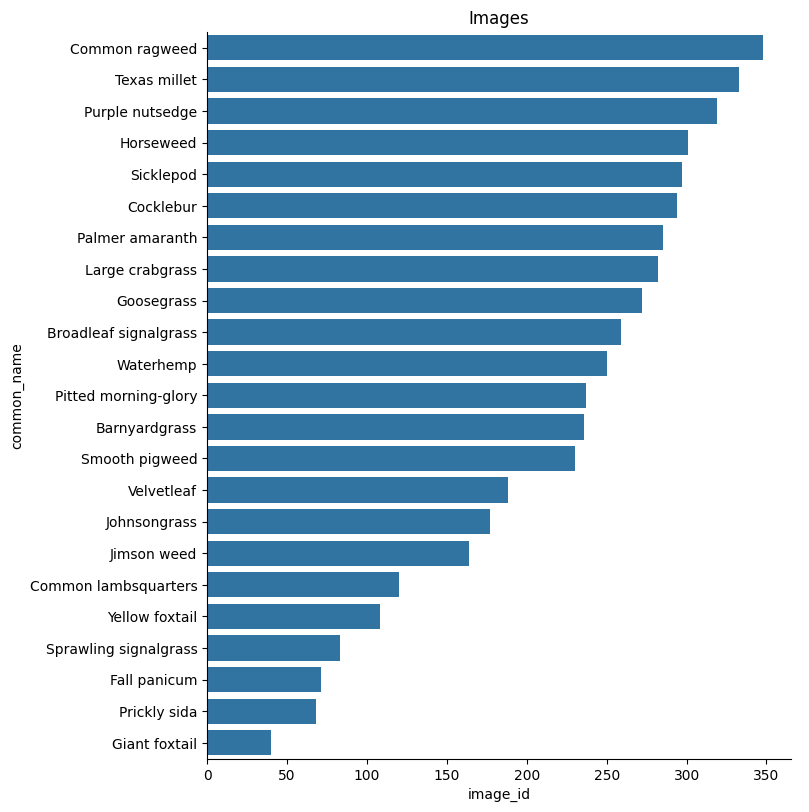

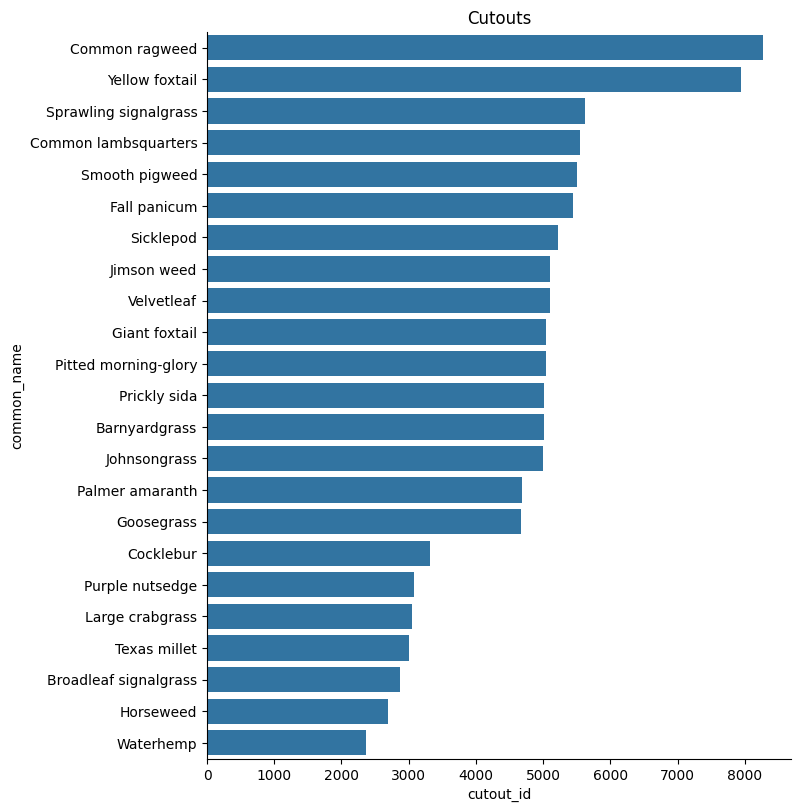

In [17]:
# Plots
image_groupby = wdf.groupby(["common_name"])["image_id"].nunique().reset_index().sort_values(by="image_id", ascending=False)
sns.catplot(image_groupby, y="common_name", x="image_id", kind="bar", height=8)
plt.tight_layout()
plt.title("Images")
plt.savefig("/home/mkutuga/SemiF-ImageCuration/data/balanced_data/balanced_weeds_images.png")
cutout_groupby = wdf.groupby(["common_name"])["cutout_id"].nunique().reset_index().sort_values(by="cutout_id", ascending=False)
sns.catplot(cutout_groupby, y="common_name", x="cutout_id", kind="bar", height=8)
plt.tight_layout()
plt.title("Cutouts")
plt.savefig("/home/mkutuga/SemiF-ImageCuration/data/balanced_data/balanced_weeds_cutouts.png")

## Covers

In [18]:
# Function to sample from each group
def balanced_cover_sampling(group):
    # Desired sample size in terms of number of images for each common name
    # This is a simplified example; adjust as needed
    desired_images_per_group = 250
    desired_cutouts_per_group = 5000 # Example target, adjust as needed
    # Sort by cutout_count to increase chances of balanced cutout_counts
    group = group.sort_values(by='cutout_id', ascending=False)
    sampled_rows = []
    imgs = []
    images_sampled = 0
    cutouts_sampled = 0
    for _, row in group.iterrows():
        if images_sampled < desired_images_per_group and cutouts_sampled < desired_cutouts_per_group:
            sampled_rows.append(row)
            
            img = row["image_id"]
            cut = row["cutout_id"]
            if img not in imgs:
                imgs.append(img)
                images_sampled += 1
            cutouts_sampled += cut
    return pd.DataFrame(sampled_rows)

In [19]:
# Filter for weeds
# Filter for weeds and exclude cover crops and cash crops
covers_mdf = mdf[mdf["general_season"]=="cover crops"]
# group the dataframe by number of cutouts per images by species
grouped_covers = covers_mdf.groupby(["batch_id","image_id", "common_name"])["cutout_id"].nunique().reset_index(name="cutout_id")
# Group by 'common_name' and apply sampling function
shuffled_grouped_covers = grouped_covers.sample(frac=1, random_state=42)
sampled_covers = shuffled_grouped_covers.groupby('common_name').apply(balanced_cover_sampling).reset_index(drop=True).sort_values(by="cutout_id", ascending=False)
sampled_covers = sampled_covers[sampled_covers["common_name"]!="Horseweed"]
wdf = df.copy()

wdf = wdf[wdf["image_id"].isin(sampled_covers["image_id"])]
wdf = wdf.drop_duplicates(subset="cutout_id")
# Removed non-weed instances like colorchecker images and unknown classes
wdf = wdf[wdf["common_name"]!= "Colorchecker"]
wdf = wdf[wdf["common_name"]!= "Unknown"]
# Remove low number weeds
wdf = wdf[wdf["common_name"]!="Spiny amaranth"]
wdf = wdf[wdf["common_name"]!="Common sunflower"]
wdf = wdf[wdf["common_name"]!="Ragweed parthenium"]
wdf = wdf[wdf["common_name"]!="Jungle rice"]
wdf = wdf[wdf["common_name"]!="Kochia"]
# Removed non-weed instances
wdf = wdf[wdf["common_name"]!="Maize"]
wdf = wdf[wdf["common_name"]!="Soybean"]
wdf = wdf[wdf["common_name"]!="Palmer amaranth"]
wdf = wdf[wdf["common_name"]!="Large crabgrass"]
wdf = wdf[wdf["common_name"]!="Horseweed"]
wdf = wdf[wdf["common_name"]!="Goosegrass"]

wdf.reset_index(drop=True).to_csv("/home/mkutuga/SemiF-ImageCuration/data/balanced_data/balanced_covers.csv", index=False)
wdf

/tmp/ipykernel_2444091/1617467021.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_covers = shuffled_grouped_covers.groupby('common_name').apply(balanced_cover_sampling).reset_index(drop=True).sort_values(by="cutout_id", ascending=False)


,data_root,season,batch_id,image_id,bbox,datetime,hwc,cutout_id,cutout_num,cutout_path,...,is_green,exg_sum,hex_11,rgb_11,occurences_11,shape,state_id,date,dt,general_season
260999,semifield-cutouts,cover crops 2022/2023,MD_2022-11-07,MD_1667830362,"{'bbox_id': 'MD_1667830362_0', 'image_id': 'MD...",2022:11:07 10:12:55,"[365, 485, 3]",MD_1667830362_0,0,MD_2022-11-07/MD_1667830362_0.png,...,None,NaN,None,None,NaN,None,MD,2022-11-07,2022-11-07,cover crops
261000,semifield-cutouts,cover crops 2022/2023,MD_2022-11-07,MD_1667830362,"{'bbox_id': 'MD_1667830362_1', 'image_id': 'MD...",2022:11:07 10:12:55,"[421, 507, 3]",MD_1667830362_1,1,MD_2022-11-07/MD_1667830362_1.png,...,None,NaN,None,None,NaN,None,MD,2022-11-07,2022-11-07,cover crops
261001,semifield-cutouts,cover crops 2022/2023,MD_2022-11-07,MD_1667830362,"{'bbox_id': 'MD_1667830362_2', 'image_id': 'MD...",2022:11:07 10:12:55,"[788, 643, 3]",MD_1667830362_2,2,MD_2022-11-07/MD_1667830362_2.png,...,None,NaN,None,None,NaN,None,MD,2022-11-07,2022-11-07,cover crops
261002,semifield-cutouts,cover crops 2022/2023,MD_2022-11-07,MD_1667830362,"{'bbox_id': 'MD_1667830362_3', 'image_id': 'MD...",2022:11:07 10:12:55,"[324, 354, 3]",MD_1667830362_3,3,MD_2022-11-07/MD_1667830362_3.png,...,None,NaN,None,None,NaN,None,MD,2022-11-07,2022-11-07,cover crops
261003,semifield-cutouts,cover crops 2022/2023,MD_2022-11-07,MD_1667830362,"{'bbox_id': 'MD_1667830362_4', 'image_id': 'MD...",2022:11:07 10:12:55,"[529, 583, 3]",MD_1667830362_4,4,MD_2022-11-07/MD_1667830362_4.png,...,None,NaN,None,None,NaN,None,MD,2022-11-07,2022-11-07,cover crops
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038662,semifield-cutouts,cover crops 2023/2024,MD_2023-09-29,MD_1696009717,"{'bbox_id': 'MD_1696009717_37', 'image_id': 'M...",2023:09:29 13:45:53,"[112, 324, 3]",MD_1696009717_37,37,MD_2023-09-29/MD_1696009717_37.png,...,None,NaN,None,None,NaN,None,MD,2023-09-29,2023-09-29,cover crops
1038663,semifield-cutouts,cover crops 2023/2024,MD_2023-09-29,MD_1696009717,"{'bbox_id': 'MD_1696009717_38', 'image_id': 'M...",2023:09:29 13:45:53,"[179, 392, 3]",MD_1696009717_38,38,MD_2023-09-29/MD_1696009717_38.png,...,None,NaN,None,None,NaN,None,MD,2023-09-29,2023-09-29,cover crops
1038664,semifield-cutouts,cover crops 2023/2024,MD_2023-09-29,MD_1696009717,"{'bbox_id': 'MD_1696009717_39', 'image_id': 'M...",2023:09:29 13:45:53,"[267, 125, 3]",MD_1696009717_39,39,MD_2023-09-29/MD_1696009717_39.png,...,None,NaN,None,None,NaN,None,MD,2023-09-29,2023-09-29,cover crops
1038665,semifield-cutouts,cover crops 2023/2024,MD_2023-09-29,MD_1696009717,"{'bbox_id': 'MD_1696009717_40', 'image_id': 'M...",2023:09:29 13:45:53,"[159, 553, 3]",MD_1696009717_40,40,MD_2023-09-29/MD_1696009717_40.png,...,None,NaN,None,None,NaN,None,MD,2023-09-29,2023-09-29,cover crops


In [20]:
print("total number of images: ", wdf.image_id.nunique())
print("total number of cutouts: ", wdf.cutout_id.nunique())
print("total species: ", wdf.common_name.nunique())
print("average number of instances per image: ", wdf.cutout_id.nunique() // wdf.image_id.nunique())
print("average number of images per species: ", wdf.image_id.nunique() // wdf.common_name.nunique())
print("average number of instances per species: ", wdf.cutout_id.nunique() // wdf.common_name.nunique())

cutdf = wdf.reset_index(drop=True).groupby(["common_name"])["image_id"].nunique().reset_index()
cutdf = cutdf.groupby(['common_name'])['image_id'].mean().reset_index(name='average_counts').sort_values(by="average_counts")
print(f"min number of images/species: {cutdf.iloc[0]['average_counts']} ({cutdf.iloc[0]['common_name']})")
print(f"max number of images/species: {cutdf.iloc[-1]['average_counts']} ({cutdf.iloc[-1]['common_name']})")
cutdf = wdf.reset_index(drop=True).groupby(["common_name"])["cutout_id"].nunique().reset_index()
cutdf = cutdf.groupby(['common_name'])['cutout_id'].mean().reset_index(name='average_counts').sort_values(by="average_counts")
print(f"min number of cutouts/species: {cutdf.iloc[0]['average_counts']} ({cutdf.iloc[0]['common_name']})")
print(f"max number of cutouts/species: {cutdf.iloc[-1]['average_counts']} ({cutdf.iloc[-1]['common_name']})")

total number of images:  1174
total number of cutouts:  60469
total species:  12
average number of instances per image:  51
average number of images per species:  97
average number of instances per species:  5039
min number of images/species: 18.0 (Red clover)
max number of images/species: 263.0 (Mustards)
min number of cutouts/species: 4488.0 (Mustards)
max number of cutouts/species: 5253.0 (Black oats)


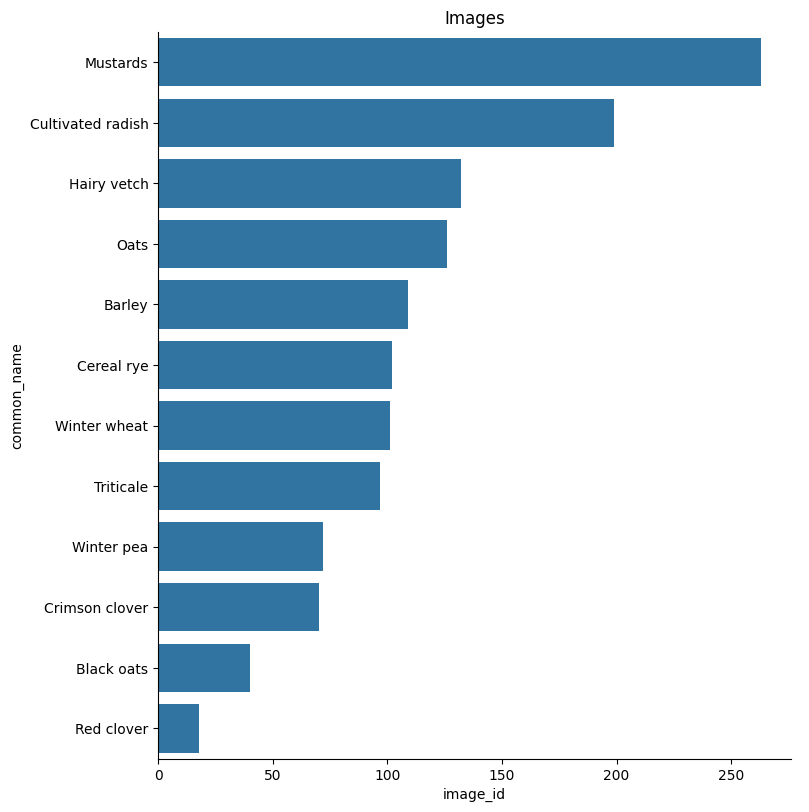

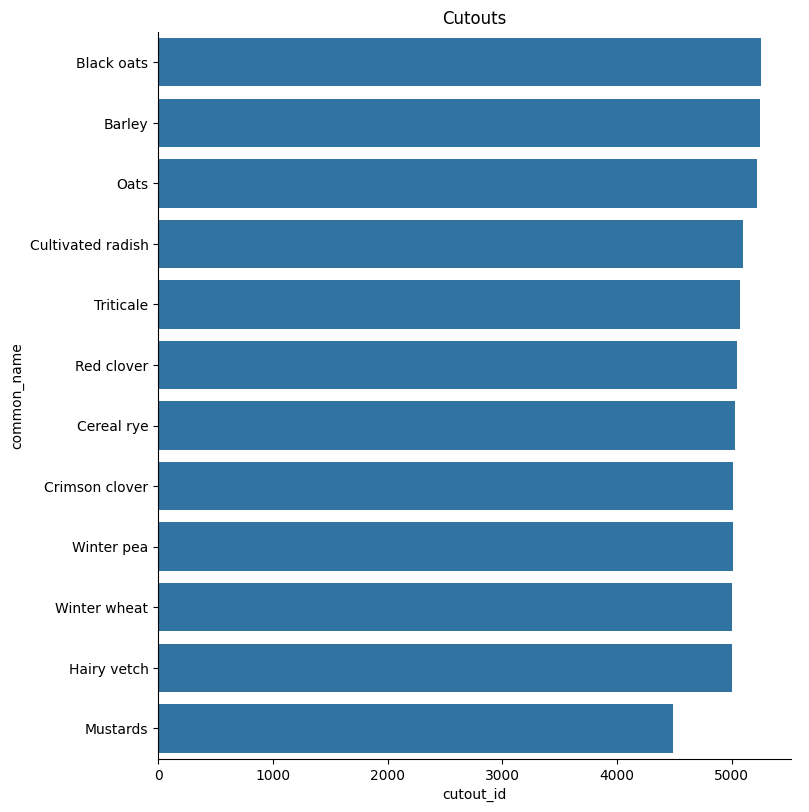

In [21]:
import matplotlib.pyplot as plt
# Plots
image_groupby = wdf.groupby(["common_name"])["image_id"].nunique().reset_index().sort_values(by="image_id", ascending=False)
sns.catplot(image_groupby, y="common_name", x="image_id", kind="bar", height=8)
plt.tight_layout()
plt.title("Images")
plt.savefig("/home/mkutuga/SemiF-ImageCuration/data/balanced_data/balanced_covers_images.png")
cutout_groupby = wdf.groupby(["common_name"])["cutout_id"].nunique().reset_index().sort_values(by="cutout_id", ascending=False)
sns.catplot(cutout_groupby, y="common_name", x="cutout_id", kind="bar", height=8)
plt.tight_layout()
plt.title("Cutouts")
plt.savefig("/home/mkutuga/SemiF-ImageCuration/data/balanced_data/balanced_covers_cutouts.png")

## Cash Crop Balanceing

In [22]:
# Function to sample from each group
def balanced_cash_sampling(group):
    # Desired sample size in terms of number of images for each common name
    # This is a simplified example; adjust as needed
    desired_images_per_group = 250
    desired_cutouts_per_group = 5000 # Example target, adjust as needed
    # Sort by cutout_count to increase chances of balanced cutout_counts
    group = group.sort_values(by='cutout_id', ascending=False)
    sampled_rows = []
    imgs = []
    images_sampled = 0
    cutouts_sampled = 0
    for _, row in group.iterrows():
        if images_sampled < desired_images_per_group and cutouts_sampled < desired_cutouts_per_group:
            sampled_rows.append(row)
            
            img = row["image_id"]
            cut = row["cutout_id"]
            if img not in imgs:
                imgs.append(img)
                images_sampled += 1
            cutouts_sampled += cut
    return pd.DataFrame(sampled_rows)

In [23]:
# Filter for weeds
# Filter for weeds and exclude cover crops and cash crops
cash_mdf = mdf[mdf["general_season"]=="cash crops"]
# group the dataframe by number of cutouts per images by species
grouped_cash = cash_mdf.groupby(["batch_id","image_id", "common_name"])["cutout_id"].nunique().reset_index(name="cutout_id")
# Group by 'common_name' and apply sampling function
shuffled_grouped_cash = grouped_cash.sample(frac=1, random_state=42)
sampled_cash = shuffled_grouped_cash.groupby('common_name').apply(balanced_cash_sampling).reset_index(drop=True).sort_values(by="cutout_id", ascending=False)
sampled_cash = sampled_cash[sampled_cash["common_name"]!="Horseweed"]
wdf = df.copy()

wdf = wdf[wdf["image_id"].isin(sampled_cash["image_id"])]
wdf = wdf.drop_duplicates(subset="cutout_id")
# Removed non-weed instances like colorchecker images and unknown classes
wdf = wdf[wdf["common_name"]!= "Colorchecker"]
wdf = wdf[wdf["common_name"]!= "Unknown"]
# Remove low number weeds
wdf = wdf[wdf["common_name"]!="Spiny amaranth"]
wdf = wdf[wdf["common_name"]!="Common sunflower"]
wdf = wdf[wdf["common_name"]!="Ragweed parthenium"]
wdf = wdf[wdf["common_name"]!="Jungle rice"]
wdf = wdf[wdf["common_name"]!="Kochia"]
# Removed non-weed instances
wdf = wdf[wdf["common_name"]!="Palmer amaranth"]
wdf = wdf[wdf["common_name"]!="Large crabgrass"]
wdf = wdf[wdf["common_name"]!="Horseweed"]
wdf = wdf[wdf["common_name"]!="Goosegrass"]

wdf.reset_index(drop=True).to_csv("/home/mkutuga/SemiF-ImageCuration/data/balanced_data/balanced_cashcrops.csv", index=False)
wdf

/tmp/ipykernel_2444091/879983927.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_cash = shuffled_grouped_cash.groupby('common_name').apply(balanced_cash_sampling).reset_index(drop=True).sort_values(by="cutout_id", ascending=False)


,data_root,season,batch_id,image_id,bbox,datetime,hwc,cutout_id,cutout_num,cutout_path,...,is_green,exg_sum,hex_11,rgb_11,occurences_11,shape,state_id,date,dt,general_season
155718,semifield-cutouts,weeds 2022,NC_2022-07-14,NC_1657826369,None,2022:07:14 15:18:22,None,NC_1657826369_0,0,NC_2022-07-14/NC_1657826369_0.png,...,True,NaN,None,None,NaN,None,NC,2022-07-14,2022-07-14,cash crops
155719,semifield-cutouts,weeds 2022,NC_2022-07-14,NC_1657826369,None,2022:07:14 15:18:22,None,NC_1657826369_1,1,NC_2022-07-14/NC_1657826369_1.png,...,True,NaN,None,None,NaN,None,NC,2022-07-14,2022-07-14,cash crops
155720,semifield-cutouts,weeds 2022,NC_2022-07-14,NC_1657826369,None,2022:07:14 15:18:22,None,NC_1657826369_2,2,NC_2022-07-14/NC_1657826369_2.png,...,True,NaN,None,None,NaN,None,NC,2022-07-14,2022-07-14,cash crops
155721,semifield-cutouts,weeds 2022,NC_2022-07-14,NC_1657826369,None,2022:07:14 15:18:22,None,NC_1657826369_3,3,NC_2022-07-14/NC_1657826369_3.png,...,True,NaN,None,None,NaN,None,NC,2022-07-14,2022-07-14,cash crops
155722,semifield-cutouts,weeds 2022,NC_2022-07-14,NC_1657826369,None,2022:07:14 15:18:22,None,NC_1657826369_4,4,NC_2022-07-14/NC_1657826369_4.png,...,True,NaN,None,None,NaN,None,NC,2022-07-14,2022-07-14,cash crops
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950855,semifield-cutouts,cash crops 2023,TX_2023-06-23,TX_1687544848,"{'bbox_id': 'TX_1687544848_29', 'image_id': 'T...",2023:06:23 12:23:27,"[25, 19, 3]",TX_1687544848_29,29,TX_2023-06-23/TX_1687544848_29.png,...,None,NaN,None,None,NaN,None,TX,2023-06-23,2023-06-23,cash crops
950856,semifield-cutouts,cash crops 2023,TX_2023-06-23,TX_1687544848,"{'bbox_id': 'TX_1687544848_31', 'image_id': 'T...",2023:06:23 12:23:27,"[17, 17, 3]",TX_1687544848_31,31,TX_2023-06-23/TX_1687544848_31.png,...,None,NaN,None,None,NaN,None,TX,2023-06-23,2023-06-23,cash crops
950857,semifield-cutouts,cash crops 2023,TX_2023-06-23,TX_1687544848,"{'bbox_id': 'TX_1687544848_32', 'image_id': 'T...",2023:06:23 12:23:27,"[21, 15, 3]",TX_1687544848_32,32,TX_2023-06-23/TX_1687544848_32.png,...,None,NaN,None,None,NaN,None,TX,2023-06-23,2023-06-23,cash crops
950858,semifield-cutouts,cash crops 2023,TX_2023-06-23,TX_1687544848,"{'bbox_id': 'TX_1687544848_34', 'image_id': 'T...",2023:06:23 12:23:27,"[249, 87, 3]",TX_1687544848_34,34,TX_2023-06-23/TX_1687544848_34.png,...,None,NaN,None,None,NaN,None,TX,2023-06-23,2023-06-23,cash crops


In [24]:
print("total number of images: ", wdf.image_id.nunique())
print("total number of cutouts: ", wdf.cutout_id.nunique())
print("total species: ", wdf.common_name.nunique())
print("average number of instances per image: ", wdf.cutout_id.nunique() // wdf.image_id.nunique())
print("average number of images per species: ", wdf.image_id.nunique() // wdf.common_name.nunique())
print("average number of instances per species: ", wdf.cutout_id.nunique() // wdf.common_name.nunique())

cutdf = wdf.reset_index(drop=True).groupby(["common_name"])["image_id"].nunique().reset_index()
cutdf = cutdf.groupby(['common_name'])['image_id'].mean().reset_index(name='average_counts').sort_values(by="average_counts")
print(f"min number of images/species: {cutdf.iloc[0]['average_counts']} ({cutdf.iloc[0]['common_name']})")
print(f"max number of images/species: {cutdf.iloc[-1]['average_counts']} ({cutdf.iloc[-1]['common_name']})")
cutdf = wdf.reset_index(drop=True).groupby(["common_name"])["cutout_id"].nunique().reset_index()
cutdf = cutdf.groupby(['common_name'])['cutout_id'].mean().reset_index(name='average_counts').sort_values(by="average_counts")
print(f"min number of cutouts/species: {cutdf.iloc[0]['average_counts']} ({cutdf.iloc[0]['common_name']})")
print(f"max number of cutouts/species: {cutdf.iloc[-1]['average_counts']} ({cutdf.iloc[-1]['common_name']})")

total number of images:  369
total number of cutouts:  15055
total species:  3
average number of instances per image:  40
average number of images per species:  123
average number of instances per species:  5018
min number of images/species: 100.0 (Maize)
max number of images/species: 140.0 (Upland cotton)
min number of cutouts/species: 5002.0 (Soybean)
max number of cutouts/species: 5042.0 (Maize)


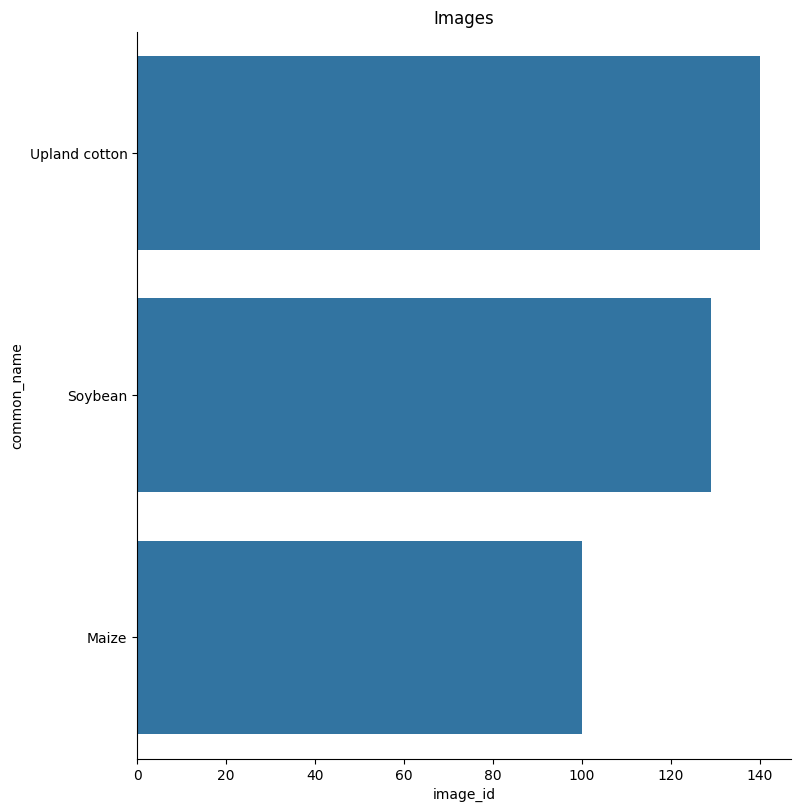

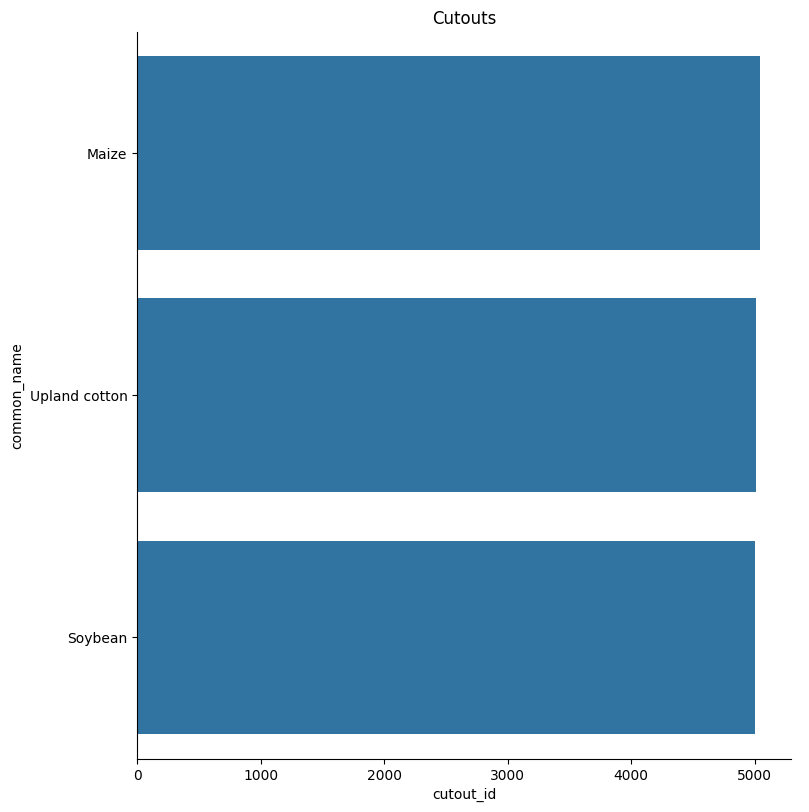

In [25]:
# Plots
image_groupby = sampled_cash.groupby(["common_name"])["image_id"].nunique().reset_index().sort_values(by="image_id", ascending=False)
sns.catplot(image_groupby, y="common_name", x="image_id", kind="bar", height=8)
plt.tight_layout()
plt.title("Images")
plt.savefig("/home/mkutuga/SemiF-ImageCuration/data/balanced_data/balanced_cash_images.png")
cutout_groupby = sampled_cash.groupby(["common_name"])["cutout_id"].sum().reset_index().sort_values(by="cutout_id", ascending=False)
sns.catplot(cutout_groupby, y="common_name", x="cutout_id", kind="bar", height=8)
plt.tight_layout()
plt.title("Cutouts")
plt.savefig("/home/mkutuga/SemiF-ImageCuration/data/balanced_data/balanced_cash_cutouts.png")

## Concatenating results

In [14]:
# csvs = [x for x in Path("/home/mkutuga/SemiF-ImageCuration/data/balanced_data").glob("*.csv")]
# csvs = [i for i in csvs if "concatenated_balanced_data" not in str(i)]
# print(csvs)
# dfs = [pd.read_csv(i, low_memory=False) for i in csvs]
# df = pd.concat(dfs)
df = pd.read_csv("/home/mkutuga/data/balanced_data/concatenated_balanced_data.csv", low_memory=False)
# df
# df.to_csv("/home/mkutuga/SemiF-ImageCuration/data/balanced_data/concatenated_balanced_data.csv", index=False)

In [15]:
df = df[["general_season", "common_name","cutout_id", "image_id"]]
df

,general_season,common_name,cutout_id,image_id
0,cash crops,Soybean,NC_1657826369_0,NC_1657826369
1,cash crops,Soybean,NC_1657826369_1,NC_1657826369
2,cash crops,Soybean,NC_1657826369_2,NC_1657826369
3,cash crops,Soybean,NC_1657826369_3,NC_1657826369
4,cash crops,Soybean,NC_1657826369_4,NC_1657826369
...,...,...,...,...
184145,weeds,Horseweed,MD_1691603883_3,MD_1691603883
184146,weeds,Horseweed,MD_1691603883_4,MD_1691603883
184147,weeds,Horseweed,MD_1691603883_5,MD_1691603883
184148,weeds,Horseweed,MD_1691603883_7,MD_1691603883


In [16]:
print(f"total_images actual: {df['image_id'].nunique()}")
print(f"total_cutouts actual: {df['cutout_id'].nunique()}")

total_images = 3879 + 1174 + 369
total_cutouts = 108626 + 60469 + 15055
print(f"total_images predicted: {total_images}")
print(f"total_cutouts predicted: {total_cutouts}")

total_images actual: 5422
total_cutouts actual: 184150
total_images predicted: 5422
total_cutouts predicted: 184150


In [88]:
image_groupby = df.groupby(["general_season", "common_name"])["image_id"].nunique().reset_index().sort_values(by="image_id", ascending=False)
cutout_groupby = df.groupby(["general_season","common_name"])["cutout_id"].nunique().reset_index().sort_values(by="cutout_id", ascending=False)
image_groupby

,general_season,common_name,image_id
19,weeds,Common ragweed,348
34,weeds,Texas millet,333
30,weeds,Purple nutsedge,319
23,weeds,Horseweed,301
31,weeds,Sicklepod,297
17,weeds,Cocklebur,294
27,weeds,Palmer amaranth,285
26,weeds,Large crabgrass,282
22,weeds,Goosegrass,272
9,cover crops,Mustards,263


In [119]:
# Create a base color palette with a distinct color for each column
green = sns.xkcd_palette(["tea"])[0] #(0.0, 0.30197616301422525, 0.12052287581699346)
blue = sns.xkcd_palette(["cool blue"])[0] #(0.03137254901960784, 0.301914648212226, 0.588404459823145)
red = sns.xkcd_palette(["dull red"])[0] #(0.7925720876585928, 0.09328719723183392, 0.11298731257208766)

# Define your base colors for each PlantType. Example:
planttype_colors = {
    "weeds": green,  # Base color for WEEDS
    "cover crops": blue,
    "cash crops": red,  # Base color for CASHCROPS
    # Add more PlantTypes if necessary
}
planttype_colors

{'weeds': (0.396078431372549, 0.6705882352941176, 0.48627450980392156),
 'cover crops': (0.28627450980392155, 0.5176470588235295, 0.7215686274509804),
 'cash crops': (0.7333333333333333, 0.24705882352941178, 0.24705882352941178)}

/home/mkutuga/miniconda3/envs/semif/lib/python3.9/site-packages/seaborn/axisgrid.py:453: RuntimeWarning: More than 1 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


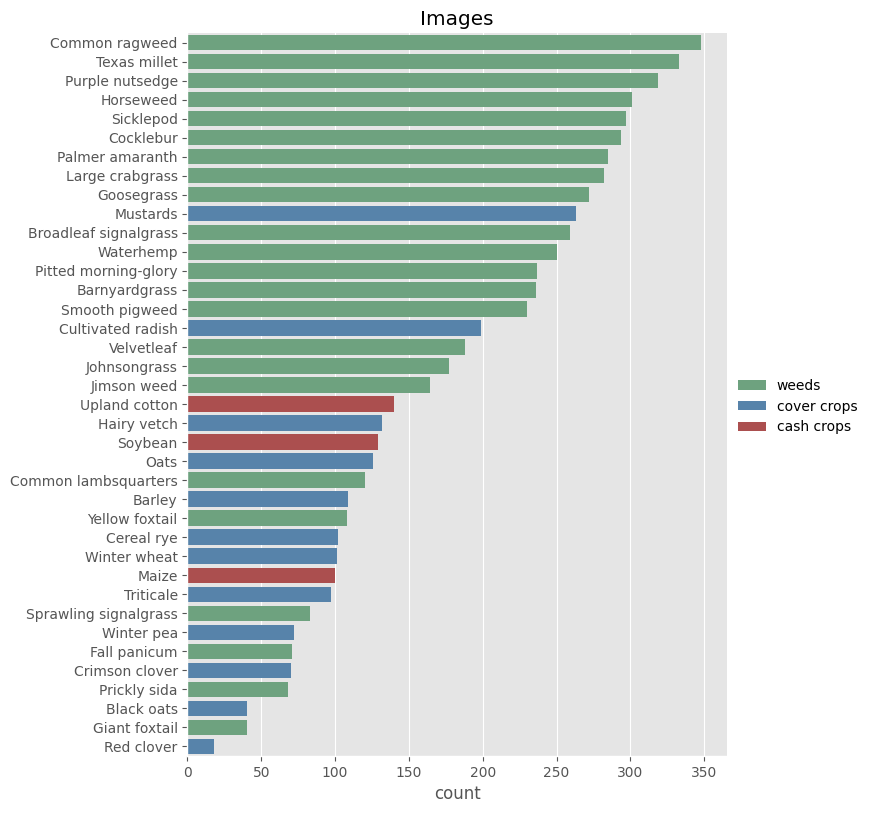

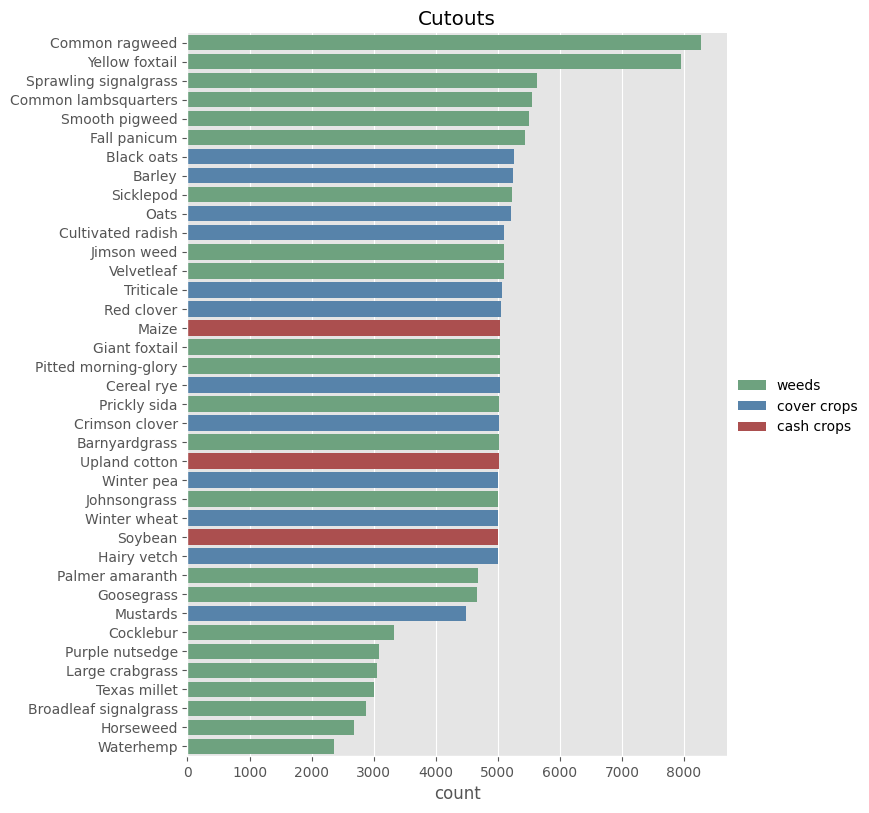

In [120]:

# Plots
style_list = [
    # "fivethirtyeight",
    "ggplot",
    # "seaborn-v0_8",
]
for style_label in style_list:
    with plt.rc_context({"figure.max_open_warning": len(style_list)}):
        with plt.style.context(style_label):
                g = sns.catplot(image_groupby, y="common_name", x="image_id", kind="bar", hue="general_season", height=8, palette=planttype_colors)
                g.set(xlabel="count", ylabel="")
                g._legend.set_title("")
                plt.title("Images")
                # plt.savefig("/home/mkutuga/SemiF-ImageCuration/data/balanced_data/overall_images.png")

                g=sns.catplot(cutout_groupby, y="common_name", x="cutout_id",hue="general_season", kind="bar", height=8,palette=planttype_colors)
                g.set(xlabel="count", ylabel="")
                g._legend.set_title("")
                plt.title("Cutouts")
                # plt.savefig("/home/mkutuga/SemiF-ImageCuration/data/balanced_data/overall_cutouts.png")